In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os
import matplotlib.pyplot as plt
import seaborn as sns

project_root = r"C:/Users/Acer/Documents/Hybrid MRS"
if project_root not in sys.path:
    sys.path.append(project_root)

from src.config import PROCESSED_DATA_DIR

metrics_path = PROCESSED_DATA_DIR / "model_comparison_metrics.csv"
df = pd.read_csv(metrics_path)

df


,model,alpha,precision_at_10,recall_at_10,ndcg_at_10
0,CF (SVD),NaN,0.244,0.028265,0.449040
1,Content (k-best),NaN,0.000,0.000000,0.000000
2,Hybrid (CF + Content),0.2,0.016,0.002685,0.066235
3,Hybrid (CF + Content),0.4,0.016,0.001545,0.082002
4,Hybrid (CF + Content),0.6,0.020,0.002393,0.086696
5,Hybrid (CF + Content),0.8,0.018,0.002328,0.078589


In [2]:

metrics_path = PROCESSED_DATA_DIR / "model_comparison_metrics.csv"
metrics = pd.read_csv(metrics_path)

metrics





,model,alpha,precision_at_10,recall_at_10,ndcg_at_10
0,CF (SVD),NaN,0.204,0.042819,0.465231
1,Content (k-best),NaN,0.000,0.000000,0.000000
2,Hybrid (CF + Content),0.2,0.006,0.000574,0.038400
3,Hybrid (CF + Content),0.4,0.006,0.000574,0.032974
4,Hybrid (CF + Content),0.6,0.010,0.000896,0.041833
5,Hybrid (CF + Content),0.8,0.012,0.001369,0.048145


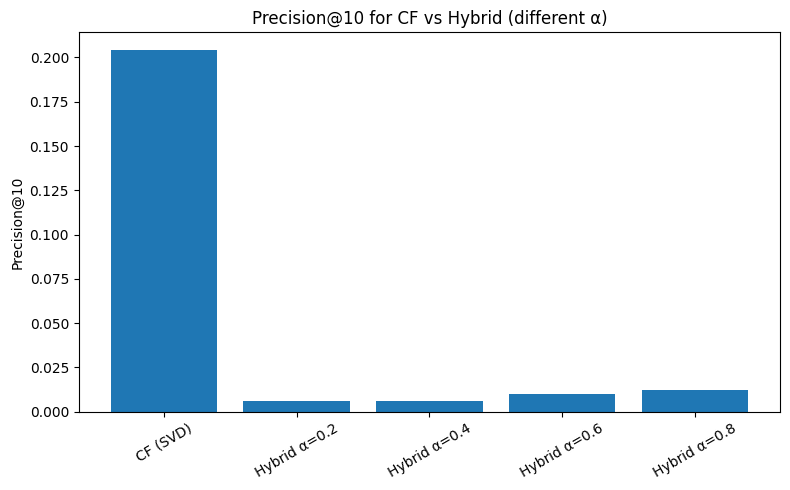

In [3]:
plt.figure(figsize=(8, 5))
mask = df["model"].str.contains("Hybrid") | df["model"].str.contains("CF")
plot_df = df[mask].copy()

# Replace NaN alpha with a string label
plot_df["alpha_label"] = plot_df["alpha"].fillna(-1).map(
    lambda x: "CF (SVD)" if x == -1 else f"Hybrid α={x}"
)

plt.bar(plot_df["alpha_label"], plot_df["precision_at_10"])
plt.ylabel("Precision@10")
plt.title("Precision@10 for CF vs Hybrid (different α)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()





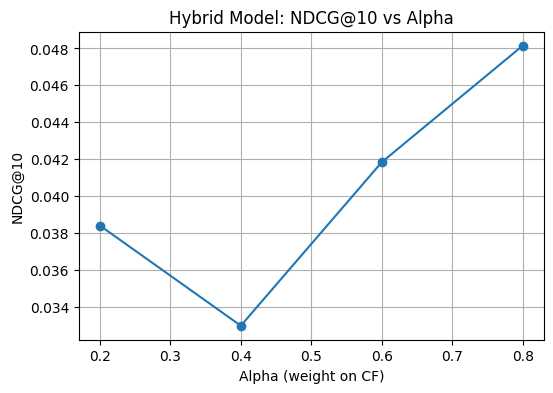

In [4]:

hybrid = metrics[metrics["model"] == "Hybrid (CF + Content)"]

plt.figure(figsize=(6,4))
plt.plot(hybrid["alpha"], hybrid["ndcg_at_10"], marker="o")
plt.xlabel("Alpha (weight on CF)")
plt.ylabel("NDCG@10")
plt.title("Hybrid Model: NDCG@10 vs Alpha")
plt.grid(True)
plt.show()

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

from src.config import PROCESSED_DATA_DIR

# Load the saved metrics
metrics_path = PROCESSED_DATA_DIR / "model_comparison_metrics.csv"
metrics = pd.read_csv(metrics_path)

print(metrics)


                   model  alpha  precision_at_10  recall_at_10  ndcg_at_10
0               CF (SVD)    NaN            0.204      0.042819    0.465231
1       Content (k-best)    NaN            0.000      0.000000    0.000000
2  Hybrid (CF + Content)    0.2            0.006      0.000574    0.038400
3  Hybrid (CF + Content)    0.4            0.006      0.000574    0.032974
4  Hybrid (CF + Content)    0.6            0.010      0.000896    0.041833
5  Hybrid (CF + Content)    0.8            0.012      0.001369    0.048145


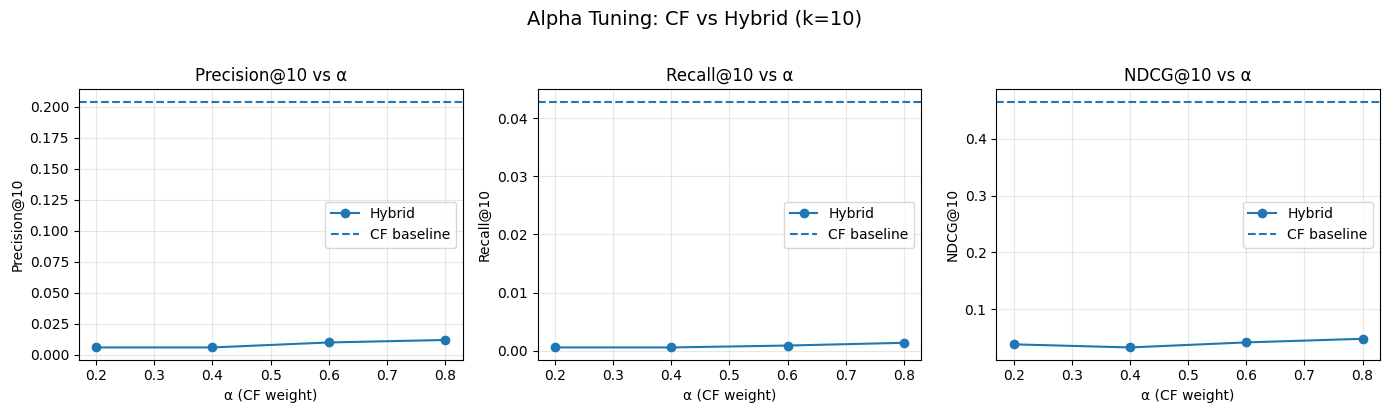

In [6]:
# Separate CF baseline and hybrid rows
cf_row = metrics[metrics["model"] == "CF (SVD)"].iloc[0]
hybrid = metrics[metrics["model"] == "Hybrid (CF + Content)"].copy()

alphas = hybrid["alpha"].values
prec_h = hybrid["precision_at_10"].values
rec_h  = hybrid["recall_at_10"].values
ndcg_h = hybrid["ndcg_at_10"].values

prec_cf = cf_row["precision_at_10"]
rec_cf  = cf_row["recall_at_10"]
ndcg_cf = cf_row["ndcg_at_10"]

plt.figure(figsize=(14, 4))
plt.suptitle("Alpha Tuning: CF vs Hybrid (k=10)", fontsize=14, y=1.02)

# ---------- Precision ----------
ax1 = plt.subplot(1, 3, 1)
ax1.plot(alphas, prec_h, marker="o", label="Hybrid")
ax1.axhline(prec_cf, linestyle="--", label="CF baseline")
ax1.set_xlabel("α (CF weight)")
ax1.set_ylabel("Precision@10")
ax1.set_title("Precision@10 vs α")
ax1.grid(True, alpha=0.3)
ax1.legend()

# ---------- Recall ----------
ax2 = plt.subplot(1, 3, 2)
ax2.plot(alphas, rec_h, marker="o", label="Hybrid")
ax2.axhline(rec_cf, linestyle="--", label="CF baseline")
ax2.set_xlabel("α (CF weight)")
ax2.set_ylabel("Recall@10")
ax2.set_title("Recall@10 vs α")
ax2.grid(True, alpha=0.3)
ax2.legend()

# ---------- NDCG ----------
ax3 = plt.subplot(1, 3, 3)
ax3.plot(alphas, ndcg_h, marker="o", label="Hybrid")
ax3.axhline(ndcg_cf, linestyle="--", label="CF baseline")
ax3.set_xlabel("α (CF weight)")
ax3.set_ylabel("NDCG@10")
ax3.set_title("NDCG@10 vs α")
ax3.grid(True, alpha=0.3)
ax3.legend()

plt.tight_layout()
# Optional: save figure
plt.savefig(PROCESSED_DATA_DIR / "alpha_tuning_cf_vs_hybrid.png", dpi=300, bbox_inches="tight")
plt.show()


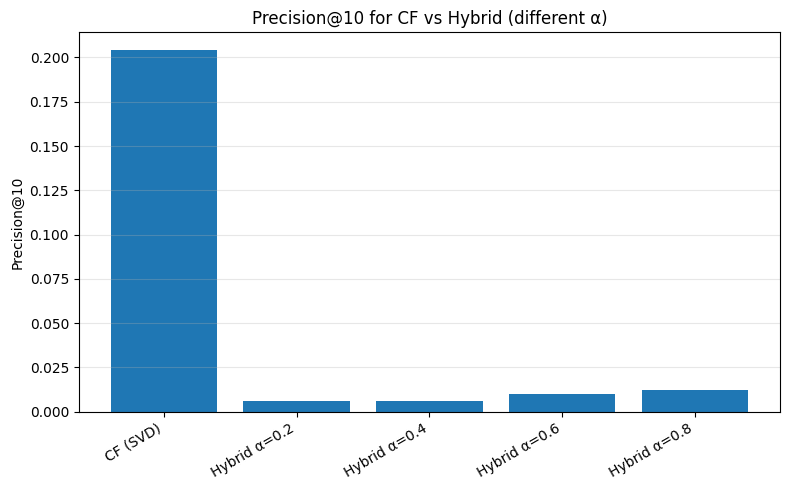

In [7]:
# Build a compact dataframe for CF + hybrid rows only
plot_df = metrics[metrics["model"].str.contains("CF")].copy()

# Create human-readable x-axis labels
plot_df["label"] = plot_df.apply(
    lambda row: "CF (SVD)" if pd.isna(row["alpha"]) else f"Hybrid α={row['alpha']}",
    axis=1,
)

plt.figure(figsize=(8, 5))
plt.bar(plot_df["label"], plot_df["precision_at_10"])
plt.ylabel("Precision@10")
plt.title("Precision@10 for CF vs Hybrid (different α)")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(PROCESSED_DATA_DIR / "precision_cf_vs_hybrid_bar.png", dpi=300, bbox_inches="tight")
plt.show()


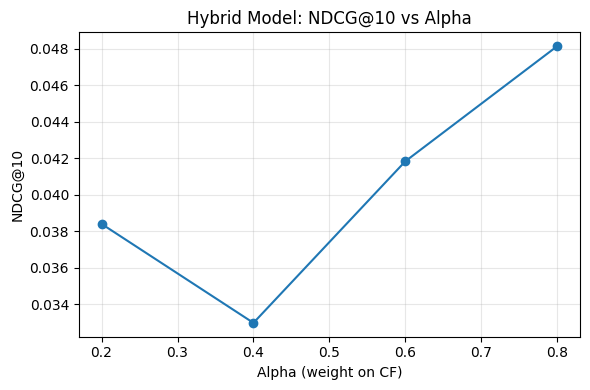

In [8]:
plt.figure(figsize=(6, 4))
plt.plot(hybrid["alpha"], hybrid["ndcg_at_10"], marker="o")
plt.xlabel("Alpha (weight on CF)")
plt.ylabel("NDCG@10")
plt.title("Hybrid Model: NDCG@10 vs Alpha")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(PROCESSED_DATA_DIR / "hybrid_ndcg_vs_alpha.png", dpi=300, bbox_inches="tight")
plt.show()
